# Titanic

算是一道入门题，完成分类任务。题目中预先给了提交样例，只根据性别来分类得到的，能达到0.7。之前使用KNN只做到了0.77，这次从头开始，使用多层感知机来完成

## 数据分析和预处理

先读取训练集和测试集，查看数据特征

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
df = pd.read_csv("dataset/train.csv")
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


量化一下标签数据，并处理缺失值。
首先要解决的是文本量化的问题。
PassengerId应该是无关的，但是Name可以反映出一定的家庭关系，他们可能会互相帮助，事发时位置也可能比较接近，但是量化有些复杂，暂时先放弃，训练完再测试效果。
Ticket大部分为数字，或者A/5.，PP之类的加上数字，可能是什么缩写，可以把他们拆分开，前缀使用标签编码，后面的数字直接保留。
Cabin缺失值过多，不好填充，暂时不使用，这里感觉如果想使用，用KNN填充可能好些。
然后剩下的Sex，Embarked都是方便量化的标签，直接使用标签编码即可

In [4]:
# Ticket
def process_Ticket(s: str):
    s = s.replace(" ", "")
    # 从字符串最后一个字符开始向前查找，直到遇到第一个非数字字符
    for i in range(len(s) - 1, -1, -1):
        if not s[i].isdigit():
            # 断开字符串，后半部分转换为int，前半部分作为str返回
            return s[: i + 1], int(s[i + 1 :]) if s[i + 1 :] else 0
    # 如果整个字符串都是数字，则前半部分为空字符串，后半部分为整个字符串的整数表示
    return "", int(s)


df[["Ticket_pre", "Ticket_num"]] = df["Ticket"].apply(
    lambda x: pd.Series(process_Ticket(x))
)
print(df[["Ticket_pre", "Ticket_num"]])

# 初始化LabelEncoder
label_encoder = LabelEncoder()
# other
for col in ["Ticket_pre", "Sex", "Embarked"]:
    df[col + "_encoder"] = label_encoder.fit_transform(df[col])

# df.info(max_cols = 17)
# print(df.columns)
# Age
median_age = df["Age"].median()
df["Age"].fillna(median_age, inplace=True)

# 归一化
for column in [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Ticket_num",
    "Ticket_pre_encoder",
    "Sex_encoder",
    "Embarked_encoder",
]:
    df[column] = (df[column] - df[column].min()) / (df[column].max() - df[column].min())
df = df[
    [
        "PassengerId",
        "Survived",
        "Pclass",
        "Age",
        "SibSp",
        "Parch",
        "Fare",
        "Ticket_num",
        "Ticket_pre_encoder",
        "Sex_encoder",
        "Embarked_encoder",
    ]
]
df.info()
df.describe()
df.to_csv("dataset/train_processed.csv", index=False)

    Ticket_pre  Ticket_num
0           A/      521171
1           PC       17599
2     STON/O2.     3101282
3                   113803
4                   373450
..         ...         ...
886                 211536
887                 112053
888      W./C.        6607
889                 111369
890                 370376

[891 rows x 2 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PassengerId         891 non-null    int64  
 1   Survived            891 non-null    int64  
 2   Pclass              891 non-null    float64
 3   Age                 891 non-null    float64
 4   SibSp               891 non-null    float64
 5   Parch               891 non-null    float64
 6   Fare                891 non-null    float64
 7   Ticket_num          891 non-null    float64
 8   Ticket_pre_encoder  891 non-null    float64
 9   Sex

C:\Users\pingter\AppData\Local\Temp\ipykernel_13016\1244432405.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(median_age, inplace=True)


In [39]:
# 分析相关性强弱
df.corr()['Survived'].sort_values(ascending=False)

Survived              1.000000
Fare                  0.257307
Parch                 0.081629
Ticket_pre_encoder    0.007538
PassengerId          -0.005007
SibSp                -0.035322
Age                  -0.064910
Ticket_num           -0.080534
Embarked_encoder     -0.163517
Pclass               -0.338481
Sex_encoder          -0.543351
Name: Survived, dtype: float64

## 训练模型
能发现一定的相关性，接下来使用神经网络来完成分类任务

train...: 100%|██████████| 1000/1000 [07:37<00:00,  2.18it/s]


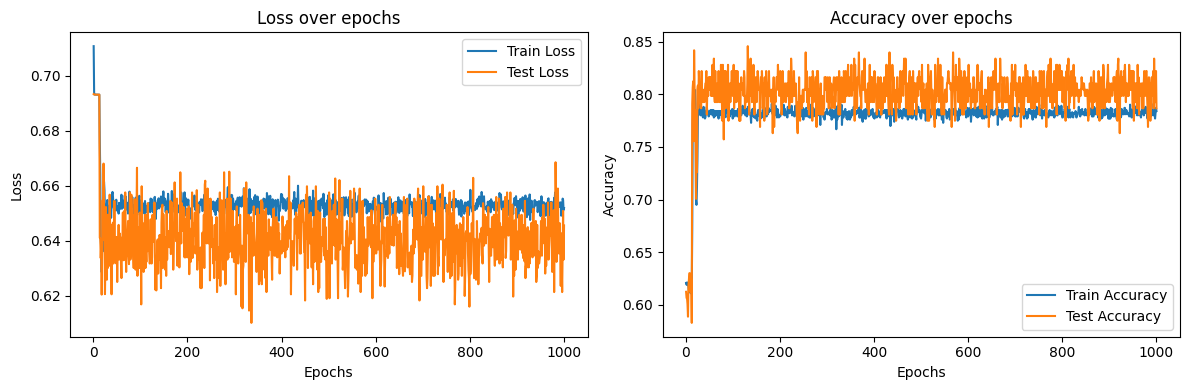

In [1]:
import torch
from torch import nn
from tqdm import tqdm
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

# 相关参数
num_epochs = 1000
learning_rate = 0.01
batch_size = 128
eps = 1e-8
torch.manual_seed(12345)


# 模型
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(9, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)


# 数据
class Dataset(torch.utils.data.Dataset):
    def __init__(self, df: pd.DataFrame) -> None:
        self.df = df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x = row[
            [
                "Pclass",
                "Age",
                "SibSp",
                "Parch",
                "Fare",
                "Ticket_num",
                "Ticket_pre_encoder",
                "Sex_encoder",
                "Embarked_encoder",
            ]
        ].values.astype(np.float32)
        y = row["Survived"].astype(np.float32)
        return torch.tensor(x, dtype=torch.float32), torch.tensor(
            y, dtype=torch.float32
        )


# 训练
def train_step(
    train_loader: torch.utils.data.DataLoader,
    net: Net,
    opt: torch.optim.Optimizer,
    loss_fn: nn.Module,
):
    net.train()
    train_loss, train_acc = 0.0, 0.0
    for data in train_loader:
        x, y = data
        y = y.view(-1, 1)
        y_pred = net(x)
        # 准确率
        pred = (y_pred >= 0.5).float()
        loss = loss_fn(y_pred, y)
        acc = torch.sum(pred == y) / y_pred.shape[0]  # y_pre.shape[0]是批次大小

        # 反向传播
        opt.zero_grad()
        loss.backward()
        opt.step()

        # 保存训练效果
        train_loss += loss.item()
        train_acc += acc
    n = len(train_loader)
    return train_loss / n, train_acc / n


# 测试
def test_step(test_loader: torch.utils.data.DataLoader, net: Net, loss_fn: nn.Module):
    net.eval()
    test_loss, test_acc = 0.0, 0.0
    with torch.inference_mode():
        for data in test_loader:
            x, y = data
            y = y.view(-1, 1)
            y_pred = net(x)

            pred = (y_pred >= 0.5).float()
            acc = torch.sum(y == pred) / y_pred.shape[0]
            test_acc += acc

            loss = loss_fn(y_pred, y)
            test_loss += loss.item()
    n = len(test_loader)
    return test_loss / n, test_acc / n


def plot_metrics(train_losses, test_losses, train_accs, test_accs, num_epochs):
    """
    绘制训练和测试损失以及准确率随训练周期变化的图像。

    参数:
    train_losses (list): 训练损失列表。
    test_losses (list): 测试损失列表。
    train_accs (list): 训练准确率列表。
    test_accs (list): 测试准确率列表。
    num_epochs (int): 训练周期数。
    """
    epochs = range(1, num_epochs + 1)

    # 绘制损失图像
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, test_losses, label="Test Loss")
    plt.title("Loss over epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    # 绘制准确率图像
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accs, label="Train Accuracy")
    plt.plot(epochs, test_accs, label="Test Accuracy")
    plt.title("Accuracy over epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    # 显示图像
    plt.tight_layout()
    plt.show()


train_losses, test_losses, train_accs, test_accs = [], [], [], []

# loader
df = pd.read_csv("./dataset/train_processed.csv")
train_size = int(len(df) * 0.8)
test_size = len(df) - train_size
train_data, test_data = torch.utils.data.random_split(
    Dataset(df), [train_size, test_size]
)

net = Net()
loss_fn = nn.BCEWithLogitsLoss()  # sigmoid和二元交叉熵
opt = torch.optim.Adam(net.parameters(), lr=learning_rate)
for epoch in tqdm(range(num_epochs), desc="train..."):
    train_loader = torch.utils.data.DataLoader(
        train_data, batch_size=batch_size, shuffle=True
    )  # 每轮训练都自动打乱
    test_loader = torch.utils.data.DataLoader(
        test_data, batch_size=batch_size, shuffle=True
    )
    train_loss, train_acc = train_step(train_loader, net, opt, loss_fn)
    test_loss, test_acc = test_step(test_loader, net, loss_fn)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
plot_metrics(train_losses, test_losses, train_accs, test_accs, num_epochs)

cpu


train...: 100%|██████████| 1000/1000 [06:18<00:00,  2.64it/s]


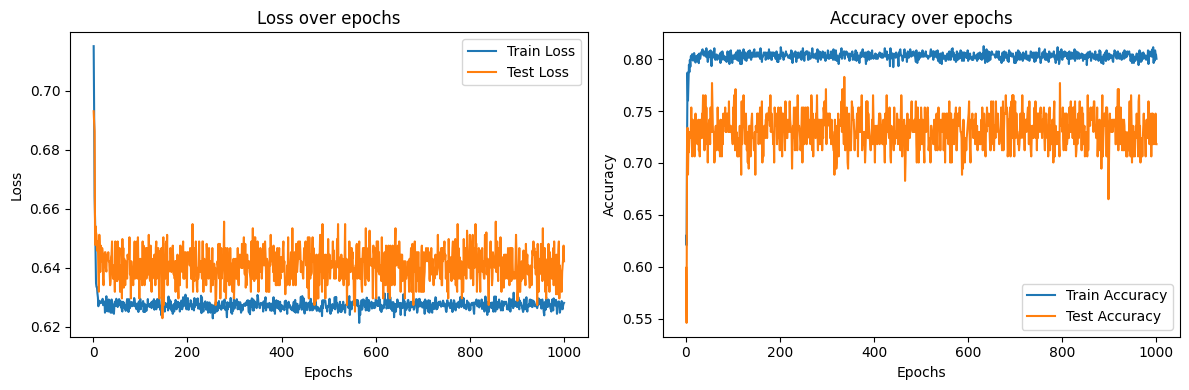

In [1]:
# 迁移到GPU版本

import torch
from torch import nn
from tqdm import tqdm
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

# 相关参数
num_epochs = 1000
learning_rate = 0.01
batch_size = 128
eps = 1e-8
torch.manual_seed(6575)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# 模型
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(9, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)


# 数据
class Dataset(torch.utils.data.Dataset):
    def __init__(self, df: pd.DataFrame) -> None:
        self.df = df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x = row[
            [
                "Pclass",
                "Age",
                "SibSp",
                "Parch",
                "Fare",
                "Ticket_num",
                "Ticket_pre_encoder",
                "Sex_encoder",
                "Embarked_encoder",
            ]
        ].values.astype(np.float32)
        y = row["Survived"].astype(np.float32)
        return torch.tensor(x, dtype=torch.float32), torch.tensor(
            y, dtype=torch.float32
        )


# 训练
def train_step(
    train_loader: torch.utils.data.DataLoader,
    net: Net,
    opt: torch.optim.Optimizer,
    loss_fn: nn.Module,
):
    net.train()
    train_loss, train_acc = 0.0, 0.0
    for data in train_loader:
        x, y = data
        x, y = x.to(device), y.to(device)
        y = y.view(-1, 1)
        y_pred = net(x)
        # 准确率
        pred = (y_pred >= 0.5).float()
        loss = loss_fn(y_pred, y)
        acc = torch.sum(pred == y) / y_pred.shape[0]  # y_pre.shape[0]是批次大小

        # 反向传播
        opt.zero_grad()
        loss.backward()
        opt.step()

        # 保存训练效果
        train_loss += loss.item()
        train_acc += acc
    n = len(train_loader)
    return train_loss / n, train_acc / n


# 测试
def test_step(test_loader: torch.utils.data.DataLoader, net: Net, loss_fn: nn.Module):
    net.eval()
    test_loss, test_acc = 0.0, 0.0
    with torch.inference_mode():
        for data in test_loader:
            x, y = data
            x, y = x.to(device), y.to(device)
            y = y.view(-1, 1)
            y_pred = net(x)

            pred = (y_pred >= 0.5).float()
            acc = torch.sum(y == pred) / y_pred.shape[0]
            test_acc += acc

            loss = loss_fn(y_pred, y)
            test_loss += loss.item()
    n = len(test_loader)
    return test_loss / n, test_acc / n


def plot_metrics(train_losses, test_losses, train_accs, test_accs, num_epochs):
    """
    绘制训练和测试损失以及准确率随训练周期变化的图像。

    参数:
    train_losses (list): 训练损失列表。
    test_losses (list): 测试损失列表。
    train_accs (list): 训练准确率列表。
    test_accs (list): 测试准确率列表。
    num_epochs (int): 训练周期数。
    """
    epochs = range(1, num_epochs + 1)

    # 绘制损失图像
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, test_losses, label="Test Loss")
    plt.title("Loss over epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    # 绘制准确率图像
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accs, label="Train Accuracy")
    plt.plot(epochs, test_accs, label="Test Accuracy")
    plt.title("Accuracy over epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    # 显示图像
    plt.tight_layout()
    plt.show()


train_losses, test_losses, train_accs, test_accs = [], [], [], []

# loader
df = pd.read_csv("./dataset/train_processed.csv")
train_size = int(len(df) * 0.8)
test_size = len(df) - train_size
train_data, test_data = torch.utils.data.random_split(
    Dataset(df), [train_size, test_size]
)

net = Net()
net = Net().to(device)  # 将整个模型迁移到GPU
loss_fn = nn.BCEWithLogitsLoss()  # sigmoid和二元交叉熵
opt = torch.optim.Adam(net.parameters(), lr=learning_rate)
for epoch in tqdm(range(num_epochs), desc="train..."):
    train_loader = torch.utils.data.DataLoader(
        train_data, batch_size=batch_size, pin_memory=True, shuffle=True
    )  # 每轮训练都自动打乱
    test_loader = torch.utils.data.DataLoader(
        test_data, batch_size=batch_size, pin_memory=True, shuffle=True
    )
    train_loss, train_acc = train_step(train_loader, net, opt, loss_fn)
    test_loss, test_acc = test_step(test_loader, net, loss_fn)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
plot_metrics(train_losses, test_losses, train_accs, test_accs, num_epochs)